# Notebook 01 — Tracking Pipeline

This notebook walks through every stage of the tracking pipeline interactively.
It is equivalent to running `scripts/run_tracking.py` but lets you inspect
intermediate outputs at each step.

## Stages
1. Setup & configuration
2. (Optional) Background subtraction
3. Draw vial ROIs
4. RF-DETR + OC-SORT tracking → wide CSV
5. Hungarian stitching → stitched long CSV
6. Vial assignment + compact IDs → compact_tracks.csv
7. Overlay video rendering

**Replace all `PLACEHOLDER` paths with your actual file paths.**

In [ ]:
import sys
sys.path.insert(0, '..')   

import json
import os
import re
import cv2
import yaml
import pandas as pd
from pathlib import Path
from IPython.display import Video

from src.preprocessing import preprocess_bgsub_gui
from src.metrics import run_diagnostics, compute_stitching_objectives, print_stitching_objectives
from src.tracking import export_tracks_xy_tuple_csv_one_config
from src.stitching import wide_to_long, build_tracklets, stitch
from src.roi import draw_and_save_vial_rois, assign_vials_and_compact_ids
from src.visualization import render_vial_overlay_video, render_raw_overlay_video
from utils import save_run_params

## 1 — Configuration

Set your paths and Roboflow credentials here.

In [ ]:
# ---- EDIT THESE ----
RAW_VIDEO = r"../data/videos/2024-02-05_NEG-008_hTDP43_WT-A90V-G287S-G294A-A315T-M337V_m/24 DPE/003/2024-02-23_NEG-008_hTDP43_WT-A90V-G287S-G294A-A315T-M337V_m_24d_003-converted-video.mp4"
MODEL_ID  = "flies-123/1"   # e.g. "flies-123/1"

# Load API key from creds_config.yaml (not committed to git)
with open("../creds_config.yaml", "r") as f:
    creds_config = yaml.safe_load(f)
API_KEY = creds_config["API_KEY"]

# Load defaults from config.yaml (override below if needed)
with open("../config.yaml") as _f:
    _cfg = yaml.safe_load(_f)
_t = _cfg.get("tracker", {})
_s = _cfg.get("stitching", {})
_p = _cfg.get("preprocessing", {})

confidence              = _t.get("confidence", 0.1)
lost_track_buffer       = _t.get("lost_track_buffer", 90)
min_matching_threshold  = _t.get("minimum_matching_threshold", 0.2)
min_consecutive_frames  = _t.get("minimum_consecutive_frames", 3)
asso_func               = _t.get("asso_func", "diou")
vial_count_cap          = _s.get("vial_count_cap", 7)
bg_gain                 = _p.get("bg_gain", 1.2)
bg_white_level          = _p.get("bg_white_level", 245)
bg_percentile           = _p.get("bg_percentile", 85.0)
bg_sample_stride        = _p.get("bg_sample_stride", 1)
default_end             = _p.get("default_end", 700)

# Auto-increment output directory: run_1, run_2, run_3, ...
_outputs_root = Path("../outputs")
_outputs_root.mkdir(parents=True, exist_ok=True)
_existing = [d for d in _outputs_root.iterdir() if d.is_dir() and d.name.startswith("run_")]
_next_n = max((int(d.name.split("_")[1]) for d in _existing if d.name.split("_")[1].isdigit()), default=0) + 1
OUTPUT_PATH = str(_outputs_root / f"run_{_next_n}")

os.makedirs(OUTPUT_PATH, exist_ok=True)
PATH_TO_VID = RAW_VIDEO

# Extract a short label from the filename: e.g. "2024-03-01_..._31d_001-converted" → "31d_n001"
# Pattern: _<age>d_<3-digit video number> anywhere in the stem.
_raw_stem = Path(RAW_VIDEO).stem
_m = re.search(r'_(\d+d)_(\d{3})', _raw_stem)
short_name = f"{_m.group(1)}_n{_m.group(2)}" if _m else _raw_stem

print("Output dir:", OUTPUT_PATH)
print("Short name:", short_name)
print(f"asso_func={asso_func}, vial_count_cap={vial_count_cap}")
print(f"bg_gain={bg_gain}, bg_white_level={bg_white_level}, bg_percentile={bg_percentile}, bg_sample_stride={bg_sample_stride}, default_end={default_end}")
_cap = cv2.VideoCapture(RAW_VIDEO)
save_run_params(OUTPUT_PATH, "config", {
    "video": RAW_VIDEO, "output_dir": OUTPUT_PATH, "short_name": short_name,
    "video_fps": _cap.get(cv2.CAP_PROP_FPS),
    "video_width": int(_cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
    "video_height": int(_cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    "video_frames": int(_cap.get(cv2.CAP_PROP_FRAME_COUNT)),
    "tracker": {"confidence": confidence, "lost_track_buffer": lost_track_buffer,
                 "min_matching_threshold": min_matching_threshold,
                 "min_consecutive_frames": min_consecutive_frames, "asso_func": asso_func},
    "preprocessing": {"bg_gain": bg_gain, "bg_white_level": bg_white_level,
                       "bg_percentile": bg_percentile, "bg_sample_stride": bg_sample_stride},
})
_cap.release()

Output dir: ..\outputs\run_57
Short name: 28d_n001
asso_func=diou, vial_count_cap=7
bg_gain=1.2, bg_white_level=245, bg_percentile=85.0, bg_sample_stride=1, default_end=700


## 2 — (Optional) Background subtraction

Opens a GUI: draw a crop ROI and choose a frame range.
The output is a `_pp.mp4` file with the **85th-percentile** background subtracted.
Skip this cell if your video already has good contrast.

In [ ]:
ROI_LIBRARY = Path("../outputs/roi_library.json")
_video_key = Path(RAW_VIDEO).stem

# Load existing library (or start fresh)
if ROI_LIBRARY.exists():
    with open(ROI_LIBRARY) as f:
        _library = json.load(f)
else:
    _library = {}

preprocess = True  # set to False to skip bg subtraction entirely

if preprocess:
    pp_out = os.path.join(OUTPUT_PATH, Path(RAW_VIDEO).stem + "_pp.mp4")
    _stored_crop = _library.get(_video_key, {}).get("preprocessing")

    if _stored_crop is not None:
        print(f"Found stored preprocessing params for: {_video_key}")
    else:
        print(f"No stored preprocessing params for: {_video_key} — opening GUI...")

    pp_path, _crop_params = preprocess_bgsub_gui(
        video_path=RAW_VIDEO,
        out_mp4=pp_out,
        default_end=default_end,
        gain=bg_gain,
        white_level=bg_white_level,
        bg_sample_stride=bg_sample_stride,
        bg_percentile=bg_percentile,
        crop_params=_stored_crop,
    )
    PATH_TO_VID = Path(pp_path)

    # Save crop params + full video path to library
    if _video_key not in _library:
        _library[_video_key] = {}
    _library[_video_key]["preprocessing"] = _crop_params
    _library[_video_key]["video_path"] = RAW_VIDEO
    ROI_LIBRARY.parent.mkdir(parents=True, exist_ok=True)
    with open(ROI_LIBRARY, "w") as f:
        json.dump(_library, f, indent=2)
    print("Preprocessing params saved to library.")

save_run_params(OUTPUT_PATH, "preprocessing", {"video_pp": str(PATH_TO_VID)})

## 3 — Draw vial ROIs

Opens an OpenCV GUI on frame 0: drag rectangles around each vial.
Press **q** when all 6 ROIs are drawn. Saved to `vial_rois.json`.

This is a one-time step — reuse the JSON for the same experimental setup.

In [ ]:
ROI_JSON = os.path.join(OUTPUT_PATH, "vial_rois.json")
_stored_vials = _library.get(_video_key, {}).get("vial_rois")

if _stored_vials is not None:
    print(f"Found stored vial ROIs for: {_video_key}")
    _vials = {k: tuple(v) for k, v in _stored_vials.items()}
    with open(ROI_JSON, "w") as f:
        json.dump({k: list(v) for k, v in _vials.items()}, f, indent=2)
    print(f"Loaded {len(_vials)} vials from library.")
else:
    print(f"No stored vial ROIs for: {_video_key} — opening GUI...")
    _vials = draw_and_save_vial_rois(video_path=str(PATH_TO_VID), roi_json_path=ROI_JSON)

    # Save to library
    if _video_key not in _library:
        _library[_video_key] = {}
    _library[_video_key]["vial_rois"] = {k: list(v) for k, v in _vials.items()}
    ROI_LIBRARY.parent.mkdir(parents=True, exist_ok=True)
    with open(ROI_LIBRARY, "w") as f:
        json.dump(_library, f, indent=2)
    print("Vial ROIs saved to library.")

save_run_params(OUTPUT_PATH, "roi", {k: list(v) for k, v in _vials.items()})

## 4 — RF-DETR + OC-SORT tracking

Runs the detector + tracker on every frame and writes a wide CSV.
This is the most time-consuming step. 

In [ ]:
WIDE_CSV = os.path.join(OUTPUT_PATH, "tracks_wide_format.csv")
#added tracker bc tracker is now exported
df_wide, tracker = export_tracks_xy_tuple_csv_one_config(
    video_path=str(PATH_TO_VID),
    output_csv=WIDE_CSV,
    api_key=API_KEY,
    model_id=MODEL_ID,
    confidence=confidence,
    lost_track_buffer=lost_track_buffer,
    minimum_matching_threshold=min_matching_threshold,
    minimum_consecutive_frames=min_consecutive_frames,
    asso_func=asso_func,
    max_frames=None,
)

print(df_wide.shape)
save_run_params(OUTPUT_PATH, "tracker_output", {
    "wide_csv": WIDE_CSV, "frames": int(df_wide.shape[0]), "track_count": int(df_wide.shape[1] - 1),
})
df_wide.head()

Saved: ..\outputs\run_56\tracks_wide_format.csv  (frames=304, tracks=72)
(304, 73)


,frame,id1,id2,id3,id4,id5,id6,id7,id8,id9,...,id110,id113,id116,id120,id121,id124,id135,id146,id151,id162
0,0,"(39.01, 303.05)","(641.23, 335.32)","(280.76, 338.65)","(509.82, 338.24)","(648.22, 349.70)","(415.78, 256.92)","(276.76, 357.07)","(656.00, 359.79)","(560.91, 361.50)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,"(37.52, 301.11)","(641.62, 334.11)","(277.85, 337.02)","(509.93, 336.71)",NaN,"(413.94, 254.48)","(276.54, 357.14)","(656.48, 359.99)","(559.00, 360.96)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,"(37.52, 299.95)","(643.01, 332.28)","(275.83, 336.04)","(510.70, 335.42)",NaN,"(412.72, 252.26)","(276.58, 357.20)","(656.33, 360.14)","(555.65, 359.84)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,"(37.30, 298.47)","(644.97, 330.99)","(274.40, 334.97)","(511.05, 334.99)",NaN,"(411.91, 250.37)","(276.90, 357.26)","(654.84, 360.03)","(556.30, 360.36)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,"(36.73, 297.20)","(645.62, 329.88)","(272.05, 333.83)","(511.11, 334.10)",NaN,"(409.88, 248.32)","(276.00, 357.51)","(653.37, 359.81)","(555.69, 360.37)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


  RUN CONFIGURATION
{
  "tracker": {
    "confidence": 0.03,
    "track_activation_threshold": 0.1,
    "lost_track_buffer": 180,
    "minimum_matching_threshold": 0.2,
    "minimum_consecutive_frames": 3,
    "min_area": 40,
    "asso_func": "diou",
    "brownian_pos_noise": 5.0
  },
  "stitching": {
    "stitching_mode": "per_vial",
    "vial_count_cap": 7,
    "general_count_cap": 56,
    "fps": 30,
    "pause_threshold": 1.0,
    "edge_fraction": 0.1,
    "min_points_for_scale": 10,
    "link_score_weights": {
      "extrap": 0.45,
      "direction": 0.4,
      "behavioral": 0.15
    },
    "direction_weights": {
      "heading_vs_gap": 0.5,
      "overall_vs_overall": 0.5
    },
    "behavioral_weights": {
      "median_velocity": 1.0,
      "pause_fraction": 1.0,
      "mean_turning_angle": 1.0,
      "mean_angular_velocity": 1.0,
      "mean_acceleration": 1.0,
      "n_large_displacements": 1.0,
      "tortuosity": 1.0
    }
  },
  "preprocessing": {
    "bg_gain": 1.2,
    "bg

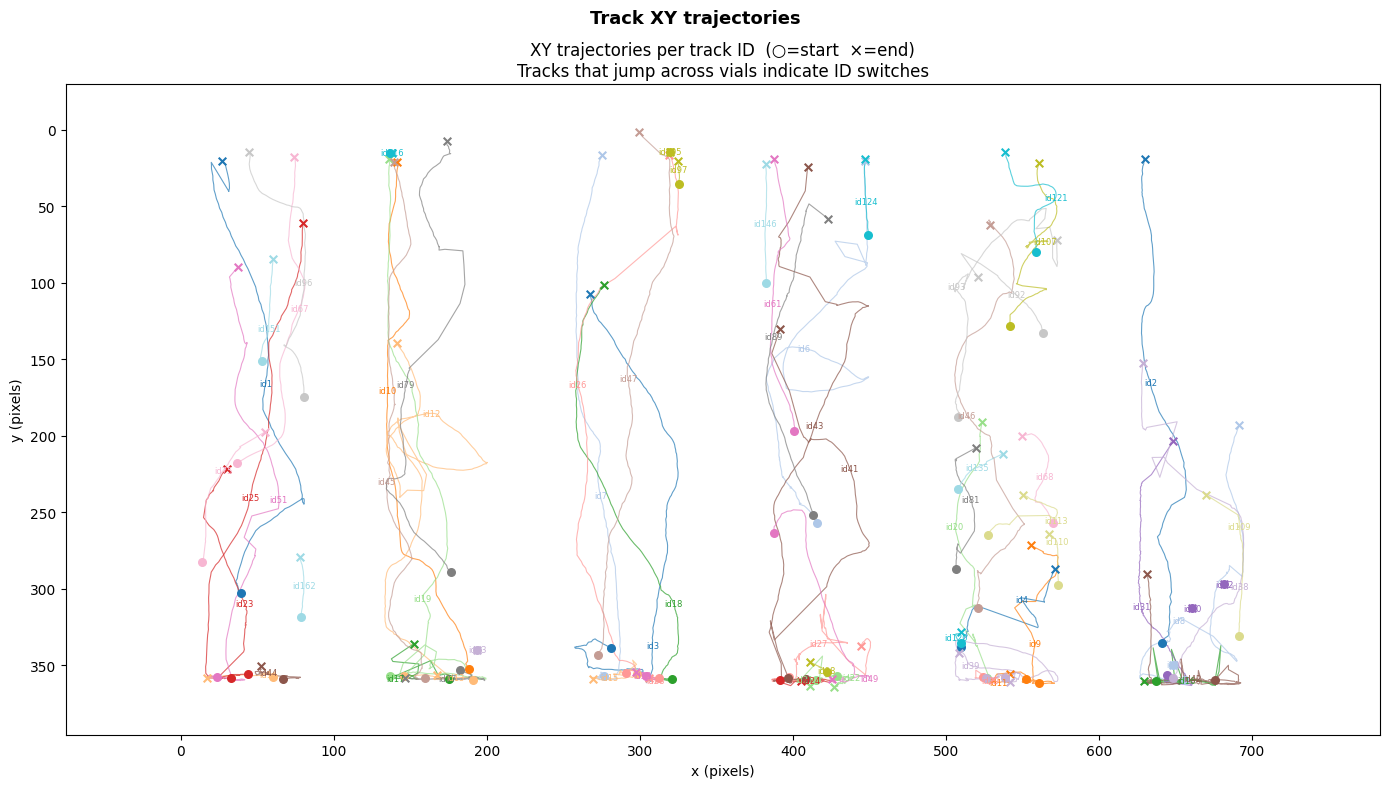

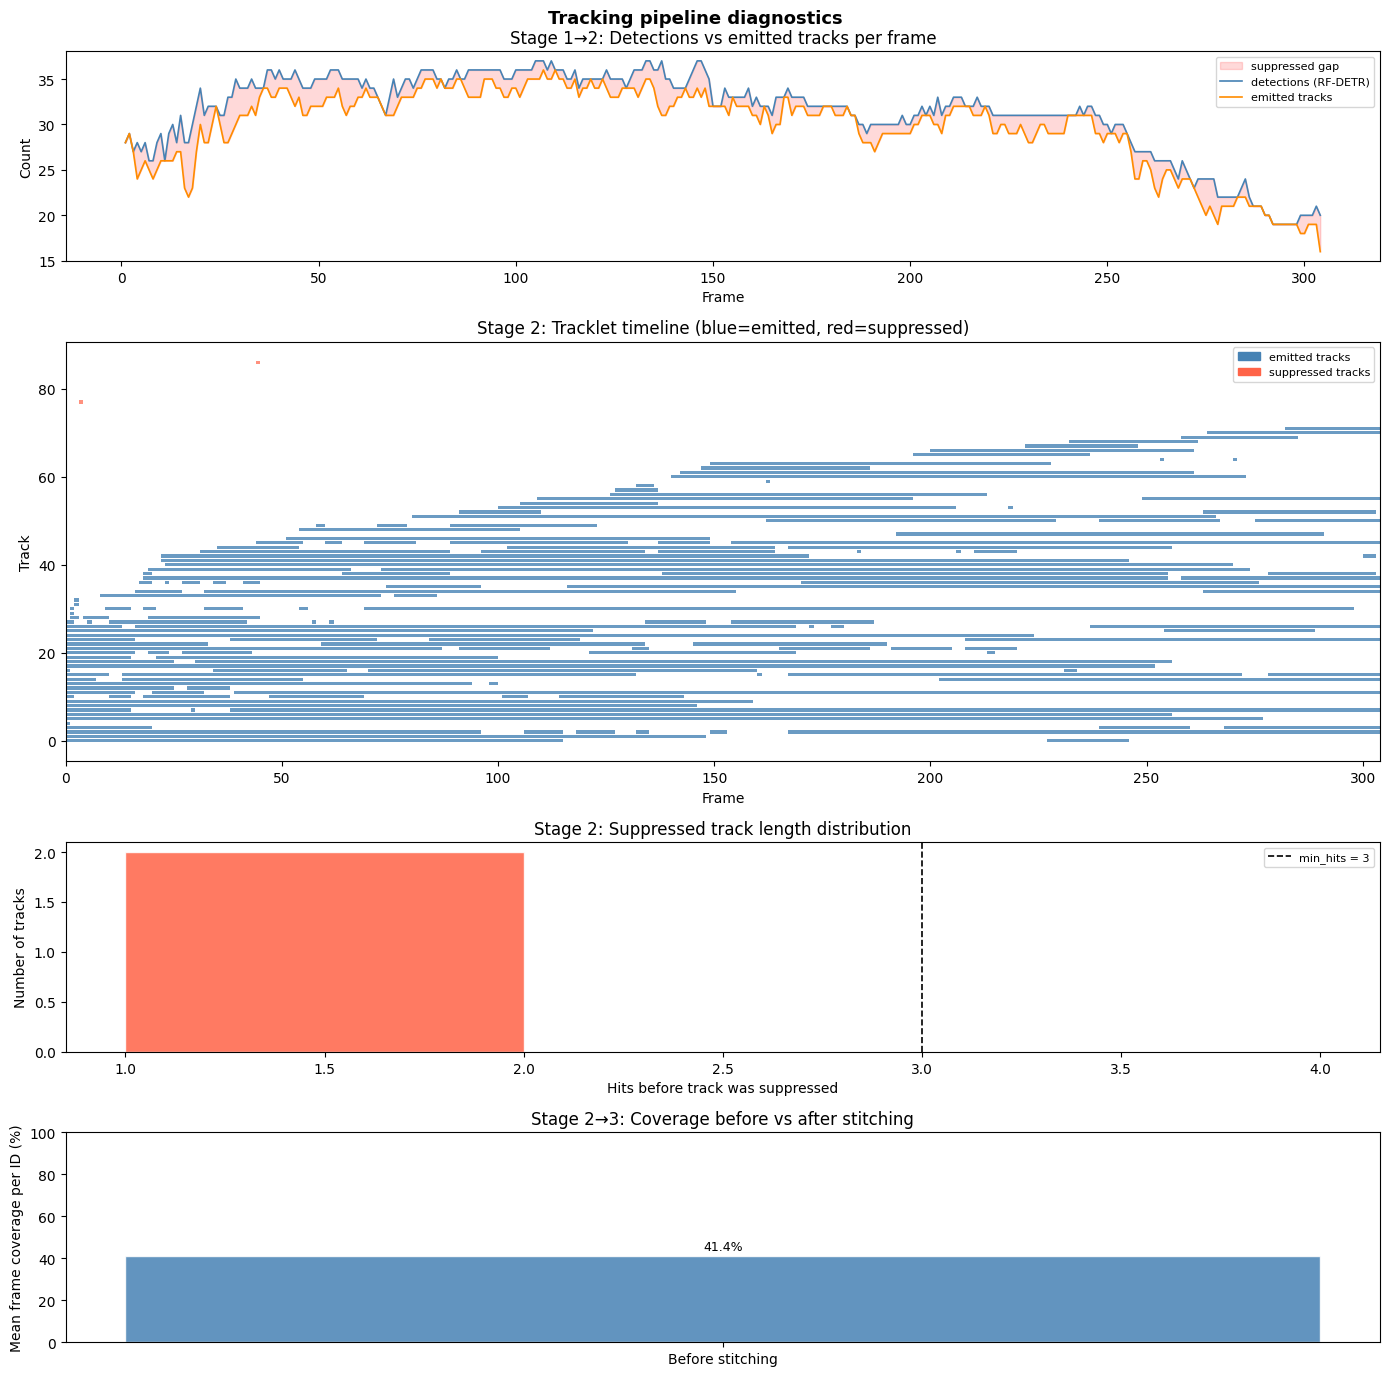

In [ ]:
# Quick mid-pipeline check: are detections reaching the tracker?
# No compact IDs yet (stitching hasn't run), so no output report saved here.
run_diagnostics(
    tracker     = tracker,
    df_wide     = df_wide,
    df_stitched = None,
    n_expected  = 42,
    fps         = 30,
    config      = _cfg,
)

## 5 — Hungarian stitching

Links fragmented tracklets across gaps using motion-consistent assignment.
Output: long CSV with `orig_id` and `stitched_id` columns.

In [ ]:
STITCHED_CSV = os.path.join(OUTPUT_PATH, "tracks_xy_stitched_long.csv")
LONG_CSV     = os.path.join(OUTPUT_PATH, "tracks_long_format.csv")

# Load vial ROIs
with open(ROI_JSON) as f:
    vial_rois = {k: tuple(v) for k, v in json.load(f).items()}

long_df   = wide_to_long(pd.read_csv(WIDE_CSV), out_csv=LONG_CSV)
tracklets = build_tracklets(long_df)

print(f"Built {len(tracklets)} tracklets from {long_df['orig_id'].nunique()} original IDs")

# Stitching — mode controlled by stitching_mode in config.yaml (default: per_vial)
stitched_df = stitch(
    long_df    = long_df,
    vial_rois  = vial_rois,
    tracklets  = tracklets,
    output_dir = OUTPUT_PATH,
)

stitched_df.to_csv(STITCHED_CSV, index=False)
print(f"\nSaved: {STITCHED_CSV}")
print(f"Stitched IDs: {stitched_df['stitched_id'].nunique()} (from {stitched_df['orig_id'].nunique()} original)")
save_run_params(OUTPUT_PATH, "stitching_output", {
    "stitched_csv": STITCHED_CSV,
    "stitched_ids": int(stitched_df["stitched_id"].nunique()),
    "original_ids": int(stitched_df["orig_id"].nunique()),
})

Built 72 tracklets from 72 original IDs
  vial1 round 1: 11 -> 7 IDs (cap 7)
  vial2 round 1: 10 -> 6 IDs (cap 7)
  vial3 round 1: 10 -> 9 IDs (cap 7)
  vial3 round 2: 9 -> 9 IDs (cap 7)
  vial3: stuck at 9 IDs, stopping
  vial4 round 1: 13 -> 11 IDs (cap 7)
  vial4 round 2: 11 -> 11 IDs (cap 7)
  vial4: stuck at 11 IDs, stopping
  vial5 round 1: 18 -> 9 IDs (cap 7)
  vial5 round 2: 9 -> 8 IDs (cap 7)
  vial5 round 3: 8 -> 7 IDs (cap 7)
  vial6 round 1: 10 -> 7 IDs (cap 7)

Saved: ..\outputs\run_56\tracks_xy_stitched_long.csv
Stitched IDs: 47 (from 72 original)


## 6 — Vial assignment + compact IDs

Assigns each point to a vial using the ROI JSON, then assigns compact sequential IDs
(left → right within each vial).

In [ ]:
COMPACT_CSV = os.path.join(OUTPUT_PATH, "compact_tracks.csv")

df_compact = assign_vials_and_compact_ids(
    stitched_csv=STITCHED_CSV,
    roi_json=ROI_JSON,
    out_csv=COMPACT_CSV,
    fps=_s.get("fps", 60),
)

print(df_compact.shape)
save_run_params(OUTPUT_PATH, "compact", {"csv": COMPACT_CSV, "rows": int(df_compact.shape[0])})
df_compact.head()

(9046, 8)


,frame,orig_id,x,y,stitched_id,vial_id,compact_id,fps
0,0,id1,39.01,303.05,id1,vial1,4,30.0
1,1,id1,37.52,301.11,id1,vial1,4,30.0
2,2,id1,37.52,299.95,id1,vial1,4,30.0
3,3,id1,37.30,298.47,id1,vial1,4,30.0
4,4,id1,36.73,297.20,id1,vial1,4,30.0


In [ ]:
num_frames = int(df_wide["frame"].max()) + 1
stitching_objectives = compute_stitching_objectives(
    df_stitched       = stitched_df,
    vial_rois         = vial_rois,
    num_frames        = num_frames,
    expected_per_vial = _s.get("expected_per_vial", 7),
    short_frac        = _s.get("short_track_frac", 0.10),
)
print_stitching_objectives(stitching_objectives)
save_run_params(OUTPUT_PATH, "stitching_objectives", {k: float(v) for k, v in stitching_objectives.items()})

# Full diagnostics: all three stages with compact IDs after stitching.
# Saves metrics_report.md + two PNG plots to OUTPUT_PATH.
run_diagnostics(
    tracker              = tracker,
    df_wide              = df_wide,
    df_stitched          = df_compact,
    df_compact           = df_compact,
    n_expected           = 42,
    fps                  = 30,
    vial_rois            = vial_rois,
    config               = _cfg,
    output_dir           = OUTPUT_PATH,
    stitching_objectives = stitching_objectives,
)

## 7 — Overlay video

Renders each fly as a coloured dot on the original video.

In [ ]:
RAW_OVERLAY_MP4 = os.path.join(OUTPUT_PATH, f"{short_name}_overlay_raw_ocsort.mp4")
OVERLAY_MP4     = os.path.join(OUTPUT_PATH, f"{short_name}_overlay_vials_shaded.mp4")

render_raw_overlay_video(
    video_path=str(PATH_TO_VID),
    csv_path=LONG_CSV,
    out_mp4=RAW_OVERLAY_MP4,
)

render_vial_overlay_video(
    video_path=str(PATH_TO_VID),
    csv_path=COMPACT_CSV,
    out_mp4=OVERLAY_MP4,
)

save_run_params(OUTPUT_PATH, "outputs", {"raw_overlay": RAW_OVERLAY_MP4, "overlay": OVERLAY_MP4})
Video(RAW_OVERLAY_MP4, width=800)

Saved raw overlay video: ..\outputs\run_56\28d_n001_overlay_raw_ocsort.mp4
Saved overlay video: ..\outputs\run_56\28d_n001_overlay_vials_shaded.mp4
